# 02_supervised_modeling (versión corregida)

Notebook robustecido para clasificación y regresión sobre RRHH con manejo de nulos, infinitos, columnas no numéricas, validaciones previas y extracción segura de importancias.


In [1]:

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, KFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)

POSSIBLE_PATHS = [
    Path('../data/03_primary/rrhh_encoded.csv'),
    Path('data/03_primary/rrhh_encoded.csv'),
    Path('/home/user/rrhh_encoded.csv')
]

RUTA = next((p for p in POSSIBLE_PATHS if p.exists()), None)
if RUTA is None:
    raise FileNotFoundError('No se encontró rrhh_encoded.csv en rutas esperadas.')

print('Archivo usado:', RUTA)


Archivo usado: ..\data\03_primary\rrhh_encoded.csv


In [2]:

df = pd.read_csv(RUTA, encoding='cp1252')
print('Shape original:', df.shape)
display(df.head())


Shape original: (286, 62)


,id_empleado,nombre,rut,departamento,cargo,fecha_ingreso,salario,tipo_contrato,jornada,antiguedad_anios,total_ausencias,dias_ausencia_total,dias_ausencia_promedio,ausencias_injustificadas,tipo_ausencia_mas_frecuente,dias_ausencia_just_no,dias_ausencia_just_sã­,total_capacitaciones,horas_capacitacion_total,horas_capacitacion_promedio,nota_promedio_capacitacion,capacitaciones_completadas,cumple_min_capacitaciones,nota_estado_abandonado,nota_estado_completado,nota_estado_en_curso,nota_estado_inscrito,total_evaluaciones,puntaje_desempeno_promedio,competencias_tecnicas_promedio,competencias_blandas_promedio,puntaje_desempeno_max,puntaje_desempeno_min,tasa_ausentismo_pct,tasa_completitud_cap,score_desempeno,segmento_desempeno,riesgo_ausentismo,salario_norm,dias_ausencia_total_norm,horas_capacitacion_total_norm,puntaje_desempeno_promedio_norm,competencias_tecnicas_promedio_std,competencias_blandas_promedio_std,tipo_contrato_enc,jornada_enc,departamento_Finanzas,departamento_Legal,departamento_Logã?Stica,departamento_Logã­Stica,departamento_Marketing,departamento_Operaciones,departamento_Rrhh,departamento_Ti,departamento_Ventas,tipo_ausencia_mas_frecuente_Desconocido,tipo_ausencia_mas_frecuente_Falta Injustificada,tipo_ausencia_mas_frecuente_Licencia Maternal,tipo_ausencia_mas_frecuente_Licencia Mã?Dica,tipo_ausencia_mas_frecuente_Licencia Mã©Dica,tipo_ausencia_mas_frecuente_Permiso,tipo_ausencia_mas_frecuente_Vacaciones
0,1,Lorena Rivera Tapia,10830786-7,Operaciones,Jefe,2015-01-01,1147033.0,Indefinido,Completa,11.4,1.0,17.0,17.00,1.0,Licencia Mã?Dica,17.0,0.0,1.0,40.0,40.0,5.70,1.0,1.0,0.0,5.7,0.0,0.0,1.0,4.20,1.7,5.80,4.2,4.2,6.8,100.0,3.77,Medio,Moderado,0.0995,0.0749,0.1370,0.6000,-0.8414,1.3004,1.0,0.0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0
1,2,Ignacio Nãºã±Ez Hernã¡Ndez,23306873-1,Logã­Stica,Analista,2015-01-12,4563559.0,Plazo Fijo,Completa,11.3,1.0,29.0,29.00,0.0,Permiso,0.0,29.0,2.0,64.0,32.0,2.65,1.0,1.0,3.2,2.1,0.0,0.0,1.0,6.30,3.9,1.30,6.3,6.3,11.6,50.0,4.58,Medio,Crítico,0.6300,0.1278,0.2192,0.9000,0.2454,-0.9899,2.0,0.0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0
2,3,Josã© Dã­Az Muã±Oz,6281564-5,Rrhh,Analista,2015-01-24,876120.0,Indefinido,Completa,11.3,3.0,38.0,12.67,1.0,Licencia Maternal,20.0,18.0,0.0,0.0,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,3.0,3.43,5.2,4.67,4.8,1.3,15.2,0.0,4.21,Medio,Crítico,0.0574,0.1674,0.0000,0.4900,0.8876,0.7253,1.0,0.0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0
3,4,Felipe Castro Muã±Oz,5967608-9,Operaciones,Analista,2015-02-04,4201812.0,Prã¡Ctica,Completa,11.3,1.0,21.0,21.00,1.0,Licencia Maternal,21.0,0.0,1.0,16.0,16.0,6.50,0.0,0.0,0.0,0.0,6.5,0.0,0.0,NaN,NaN,NaN,NaN,NaN,8.4,0.0,0.00,Bajo,Moderado,0.5738,0.0925,0.0548,0.0000,-1.6811,-1.6516,3.0,0.0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0
4,5,Carolina Zambrano Dã­Az,10140262-2,Rrhh,Coordinador,2015-02-16,1183831.0,Plazo Fijo,Completa,11.2,1.0,27.0,27.00,0.0,Licencia Mã©Dica,0.0,27.0,0.0,0.0,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,1.0,6.00,1.7,3.10,6.0,6.0,10.8,0.0,4.13,Medio,Crítico,0.1052,0.1189,0.0000,0.8571,-0.8414,-0.0738,2.0,0.0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0


## Preparación de datos


In [3]:

# ---------- Validaciones y limpieza base ----------
df = df.copy()

# Normalizar nombres de columnas
cols_originales = df.columns.tolist()
df.columns = [str(c).strip().lower().replace(' ', '_') for c in df.columns]

# Reemplazar infinitos por NaN
num_cols_all = df.select_dtypes(include=[np.number]).columns.tolist()
df[num_cols_all] = df[num_cols_all].replace([np.inf, -np.inf], np.nan)

# Definir targets posibles
possible_clf = ['segmento_desempeno', 'segmentodesempeno']
possible_reg = ['score_desempeno', 'scoredesempeno', 'puntaje_desempeno', 'puntajedesempeno']
possible_drop_extra = ['riesgo_ausentismo', 'riesgoausentismo']

target_clf = next((c for c in possible_clf if c in df.columns), None)
target_reg = next((c for c in possible_reg if c in df.columns), None)

if target_clf is None:
    raise KeyError(f'No se encontró target de clasificación. Buscados: {possible_clf}')
if target_reg is None:
    raise KeyError(f'No se encontró target de regresión. Buscados: {possible_reg}')

# Eliminar filas sin target
before_rows = len(df)
df = df[df[target_clf].notna() & df[target_reg].notna()].copy()
print(f'Filas eliminadas por target nulo: {before_rows - len(df)}')

# Features: dejar solo numéricas para simplificar el notebook
remove_cols = [c for c in [target_clf, target_reg] + possible_drop_extra if c in df.columns]
X = df.drop(columns=remove_cols, errors='ignore').copy()
X = X.select_dtypes(include=[np.number]).copy()

# Quitar columnas totalmente nulas o constantes
all_nan_cols = X.columns[X.isna().all()].tolist()
if all_nan_cols:
    print('Columnas 100% nulas eliminadas:', all_nan_cols)
    X = X.drop(columns=all_nan_cols)

constant_cols = [c for c in X.columns if X[c].nunique(dropna=True) <= 1]
if constant_cols:
    print('Columnas constantes eliminadas:', constant_cols)
    X = X.drop(columns=constant_cols)

# Targets finales
y_clf = df[target_clf].copy()
y_reg = pd.to_numeric(df[target_reg], errors='coerce')
mask_reg = y_reg.notna()

print('Target clasificación:', target_clf)
print('Target regresión:', target_reg)
print('Shape X final:', X.shape)
print('Distribución y_clf:')
print(y_clf.value_counts(dropna=False))
print('Nulos por columna en X (top 15):')
print(X.isna().sum().sort_values(ascending=False).head(15))


Filas eliminadas por target nulo: 0
Target clasificación: segmento_desempeno
Target regresión: score_desempeno
Shape X final: (286, 51)
Distribución y_clf:
segmento_desempeno
Medio    161
Bajo     115
Alto      10
Name: count, dtype: int64
Nulos por columna en X (top 15):
dias_ausencia_just_sã­            97
dias_ausencia_just_no             97
dias_ausencia_promedio            93
nota_estado_inscrito              79
nota_estado_completado            79
nota_promedio_capacitacion        79
nota_estado_en_curso              79
nota_estado_abandonado            79
horas_capacitacion_promedio       79
competencias_tecnicas_promedio    51
puntaje_desempeno_promedio        51
puntaje_desempeno_max             51
competencias_blandas_promedio     51
puntaje_desempeno_min             51
antiguedad_anios                   9
dtype: int64


In [4]:

# ---------- Split clasificación ----------
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X, y_clf,
    test_size=0.2,
    random_state=42,
    stratify=y_clf
)

# ---------- Split regresión ----------
X_reg = X.loc[mask_reg].copy()
y_reg_clean = y_reg.loc[mask_reg].copy()

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg_clean,
    test_size=0.2,
    random_state=42
)

print('Clasificación train/test:', X_train_clf.shape, X_test_clf.shape)
print('Regresión train/test:', X_train_reg.shape, X_test_reg.shape)


Clasificación train/test: (228, 51) (58, 51)
Regresión train/test: (228, 51) (58, 51)


## Modelos de clasificación


In [5]:

# ---------- Modelos de clasificación robustos ----------
cv_clf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

modelos_clf = {
    'RandomForest': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('model', RandomForestClassifier(
            n_estimators=100,
            max_depth=10,
            min_samples_split=5,
            min_samples_leaf=2,
            class_weight='balanced',
            random_state=42
        ))
    ]),
    'LogisticRegression': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(
            max_iter=1000,
            C=1.0,
            solver='lbfgs',
            class_weight='balanced',
            random_state=42
        ))
    ]),
    'GradientBoosting': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('model', GradientBoostingClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=4,
            subsample=0.8,
            random_state=42
        ))
    ])
}

resultados_clf = []
modelos_clf_ajustados = {}

for nombre, modelo in modelos_clf.items():
    try:
        modelo.fit(X_train_clf, y_train_clf)
        pred = modelo.predict(X_test_clf)
        proba = modelo.predict_proba(X_test_clf) if hasattr(modelo, 'predict_proba') else None

        fila = {
            'modelo': nombre,
            'accuracy': accuracy_score(y_test_clf, pred),
            'f1_weighted': f1_score(y_test_clf, pred, average='weighted', zero_division=0),
            'precision_weighted': precision_score(y_test_clf, pred, average='weighted', zero_division=0),
            'recall_weighted': recall_score(y_test_clf, pred, average='weighted', zero_division=0),
            'cv_f1_mean': cross_val_score(modelo, X_train_clf, y_train_clf, cv=cv_clf, scoring='f1_weighted').mean(),
            'estado': 'ok'
        }

        if proba is not None:
            try:
                fila['roc_auc_weighted'] = roc_auc_score(y_test_clf, proba, multi_class='ovr', average='weighted')
            except Exception:
                fila['roc_auc_weighted'] = np.nan
        else:
            fila['roc_auc_weighted'] = np.nan

        modelos_clf_ajustados[nombre] = modelo
    except Exception as e:
        fila = {
            'modelo': nombre,
            'accuracy': np.nan,
            'f1_weighted': np.nan,
            'precision_weighted': np.nan,
            'recall_weighted': np.nan,
            'cv_f1_mean': np.nan,
            'roc_auc_weighted': np.nan,
            'estado': f'error: {type(e).__name__}: {e}'
        }
    resultados_clf.append(fila)

resultados_clf = pd.DataFrame(resultados_clf).sort_values(['f1_weighted', 'accuracy'], ascending=False, na_position='last')
display(resultados_clf)


,modelo,accuracy,f1_weighted,precision_weighted,recall_weighted,cv_f1_mean,estado,roc_auc_weighted
2,GradientBoosting,0.948276,0.931967,0.918103,0.948276,0.871888,ok,0.995628
0,RandomForest,0.913793,0.897783,0.890653,0.913793,0.876821,ok,0.996244
1,LogisticRegression,0.896552,0.897289,0.900493,0.896552,0.898421,ok,0.983682


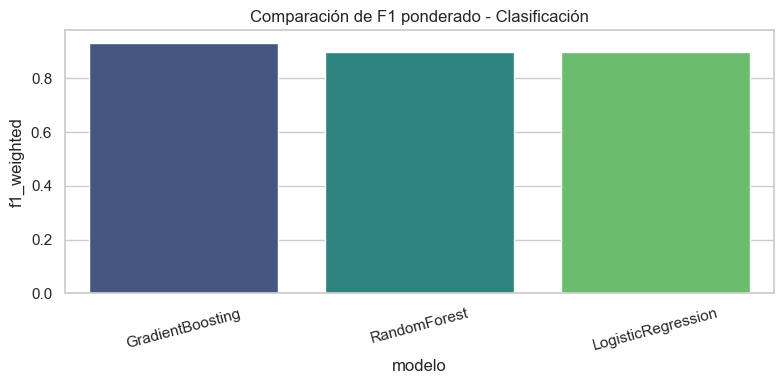

In [6]:

if not resultados_clf['f1_weighted'].dropna().empty:
    plt.figure(figsize=(8, 4))
    plot_df = resultados_clf.dropna(subset=['f1_weighted']).copy()
    sns.barplot(data=plot_df, x='modelo', y='f1_weighted', hue='modelo', dodge=False, palette='viridis', legend=False)
    plt.title('Comparación de F1 ponderado - Clasificación')
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()
else:
    print('No hay resultados válidos para graficar clasificación.')


## Modelos de regresión


In [7]:

# ---------- Modelos de regresión robustos ----------
cv_reg = KFold(n_splits=5, shuffle=True, random_state=42)

modelos_reg = {
    'RandomForest': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('model', RandomForestRegressor(
            n_estimators=100,
            max_depth=10,
            min_samples_split=5,
            min_samples_leaf=2,
            random_state=42
        ))
    ]),
    'Ridge': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', Ridge(alpha=1.0, max_iter=1000))
    ]),
    'GradientBoosting': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('model', GradientBoostingRegressor(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=4,
            subsample=0.8,
            random_state=42
        ))
    ])
}

resultados_reg = []
modelos_reg_ajustados = {}

for nombre, modelo in modelos_reg.items():
    try:
        modelo.fit(X_train_reg, y_train_reg)
        pred = modelo.predict(X_test_reg)
        rmse = mean_squared_error(y_test_reg, pred) ** 0.5
        fila = {
            'modelo': nombre,
            'mae': mean_absolute_error(y_test_reg, pred),
            'mse': mean_squared_error(y_test_reg, pred),
            'rmse': rmse,
            'r2': r2_score(y_test_reg, pred),
            'cv_rmse_mean': -cross_val_score(modelo, X_train_reg, y_train_reg, cv=cv_reg, scoring='neg_root_mean_squared_error').mean(),
            'estado': 'ok'
        }
        modelos_reg_ajustados[nombre] = modelo
    except Exception as e:
        fila = {
            'modelo': nombre,
            'mae': np.nan,
            'mse': np.nan,
            'rmse': np.nan,
            'r2': np.nan,
            'cv_rmse_mean': np.nan,
            'estado': f'error: {type(e).__name__}: {e}'
        }
    resultados_reg.append(fila)

resultados_reg = pd.DataFrame(resultados_reg).sort_values('rmse', ascending=True, na_position='last')
display(resultados_reg)


,modelo,mae,mse,rmse,r2,cv_rmse_mean,estado
1,Ridge,0.006749,0.000100,0.009988,0.999953,0.013104,ok
2,GradientBoosting,0.094925,0.015377,0.124002,0.992792,0.183159,ok
0,RandomForest,0.196417,0.067392,0.259600,0.968409,0.261350,ok


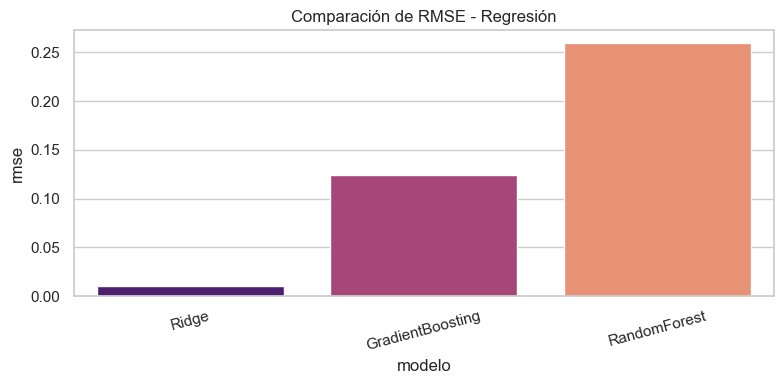

In [8]:

if not resultados_reg['rmse'].dropna().empty:
    plt.figure(figsize=(8, 4))
    plot_df = resultados_reg.dropna(subset=['rmse']).copy()
    sns.barplot(data=plot_df, x='modelo', y='rmse', hue='modelo', dodge=False, palette='magma', legend=False)
    plt.title('Comparación de RMSE - Regresión')
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()
else:
    print('No hay resultados válidos para graficar regresión.')


## Importancias de variables


,feature,importance
30,puntaje_desempeno_promedio_norm,0.152580
20,puntaje_desempeno_promedio,0.119974
31,competencias_tecnicas_promedio_std,0.108662
24,puntaje_desempeno_min,0.088804
21,competencias_tecnicas_promedio,0.083727
32,competencias_blandas_promedio_std,0.081166
23,puntaje_desempeno_max,0.080827
22,competencias_blandas_promedio,0.059785
19,total_evaluaciones,0.028796
0,id_empleado,0.021164


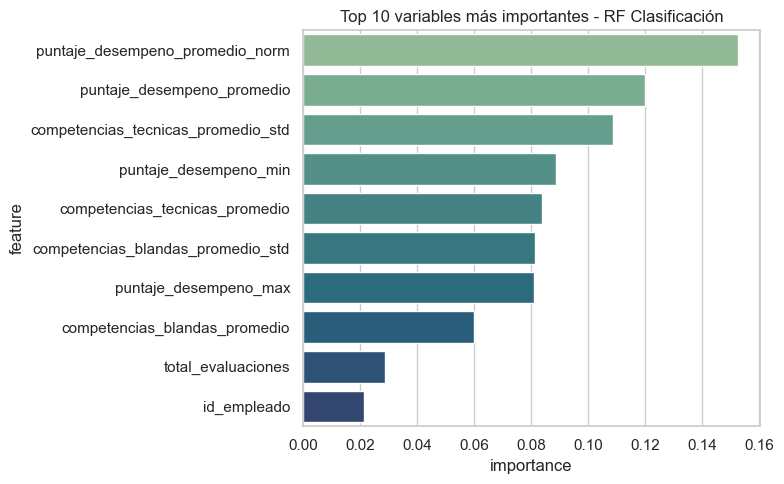

In [9]:

# ---------- Importancias de variables ----------
if 'RandomForest' in modelos_clf_ajustados:
    rf_clf = modelos_clf_ajustados['RandomForest'].named_steps['model']
    importancias_clf = pd.DataFrame({
        'feature': X_train_clf.columns,
        'importance': rf_clf.feature_importances_
    }).sort_values('importance', ascending=False).head(10)
    display(importancias_clf)

    plt.figure(figsize=(8, 5))
    sns.barplot(data=importancias_clf, y='feature', x='importance', hue='feature', dodge=False, palette='crest', legend=False)
    plt.title('Top 10 variables más importantes - RF Clasificación')
    plt.tight_layout()
    plt.show()
else:
    print('No se pudo calcular importancias: RandomForest de clasificación no quedó ajustado.')
